In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [ ]:
from quri_parts.core.operator import Operator, pauli_label, get_sparse_matrix
from quri_parts.core.state import quantum_state, apply_circuit, CircuitQuantumState
from quri_parts.circuit import QuantumCircuit
from quri_parts.qulacs.estimator import create_qulacs_vector_estimator
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm

n_qubits = 5
t = 3.0
M = 300
delta = t/M
J = 1.0

print(f' 量子ビット数: {n_qubits},\n'
      f' シミュレーション時間: {t},\n'
      f' ステップ数: {M},\n'
      f' 時間刻み: {delta},\n'
      f' 結合強度: {J}')

 量子ビット数: 5,
 シミュレーション時間: 3.0,
 ステップ数: 300,
 時間刻み: 0.01,
 結合強度: 1.0


In [ ]:
magnetization_obs = Operator({pauli_label(f"Z{i}"): 1/n_qubits for i in range(n_qubits)})
print(magnetization_obs)

0.2*Z0 + 0.2*Z1 + 0.2*Z2 + 0.2*Z3 + 0.2*Z4


In [ ]:
def get_exact_time_evolution_circuit() -> QuantumCircuit:
    """時間ステップ delta の厳密な時間発展演算子を実装した量子回路を生成する
    """
    # ハミルトニアンの構築
    hamiltonian = Operator()
    for i in range(n_qubits):
        hamiltonian.add_term(pauli_label(f"Z{i} Z{(i+1)%n_qubits}"), 1)
    hamiltonian_matrix = get_sparse_matrix(hamiltonian).toarray()

    # 厳密な時間発展回路
    exp_h = expm(-1j * hamiltonian_matrix * delta)
    circuit_exact_Ising = QuantumCircuit(n_qubits)
    circuit_exact_Ising.add_UnitaryMatrix_gate(range(n_qubits), exp_h)

    return circuit_exact_Ising

In [ ]:
def get_trotter_time_evolution_circuit() -> QuantumCircuit:
    """時間ステップ delta の時間発展演算子をトロッター分解を用いて実装した量子回路を生成する
    """
    circuit_trotter_Ising = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        circuit_trotter_Ising.add_CNOT_gate(i, (i+1)%n_qubits)
        circuit_trotter_Ising.add_RZ_gate((i+1)%n_qubits, 2*delta)
        circuit_trotter_Ising.add_CNOT_gate(i, (i+1)%n_qubits)
    return circuit_trotter_Ising

In [ ]:
# 期待値推定器の準備
estimator = create_qulacs_vector_estimator()

def run_time_evolution(
    initial_state: CircuitQuantumState,
    trotter_time_evo_circuit: QuantumCircuit,
    exact_time_evo_circuit: QuantumCircuit,
) -> tuple[list[float], list[float]]:
    """トロッター分解と厳密解の両方で時間発展を実行する
    """

    # 時間と平均磁化の値を記録するリスト
    y_trotter = []
    y_exact = []

    # t=0 における平均磁化を計算
    y_trotter.append(estimator(magnetization_obs, initial_state).value.real)
    y_exact.append(estimator(magnetization_obs, initial_state).value.real)

    # t=0 以降の平均磁化を計算
    n_qubits = initial_state.qubit_count
    for i in range(M):
        # 時間発展(delta = t/M)
        exact_circuit_i = QuantumCircuit(
                n_qubits, exact_time_evo_circuit.gates * (i+1))
        exact_state_i = apply_circuit(exact_circuit_i, initial_state)

        trotter_circuit_i = QuantumCircuit(
                n_qubits, trotter_time_evo_circuit.gates * (i+1))
        trotter_state_i = apply_circuit(trotter_circuit_i, initial_state)

        # 平均磁化を計算して記録
        y_exact.append(estimator(magnetization_obs, exact_state_i).value.real)
        y_trotter.append(estimator(magnetization_obs, trotter_state_i).value.real)

    return y_trotter, y_exact

In [ ]:
init_state = quantum_state(n_qubits)
circuit_exact_Ising = get_exact_time_evolution_circuit()
circuit_trotter_Ising = get_trotter_time_evolution_circuit()

<string>:3: DeprecationWarning: QuantumCircuit initialization takes cbit_count before gates.


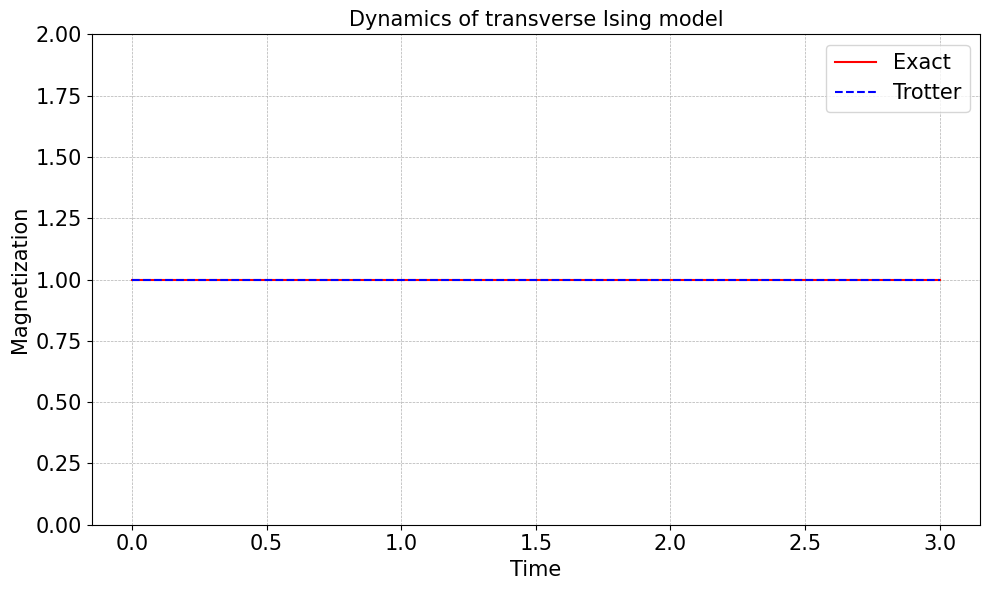

In [ ]:
y_trotter, y_exact = run_time_evolution(
     init_state, circuit_trotter_Ising, circuit_exact_Ising
)
x = [i*delta for i in range(M+1)]

plt.figure(figsize=(10, 6))
plt.xlabel("Time", fontsize=15)
plt.ylabel("Magnetization", fontsize=15)
plt.title("Dynamics of transverse Ising model", fontsize=15)
plt.plot(x, y_exact, "-", label="Exact", color="red")
plt.plot(x, y_trotter, "--", label="Trotter", color="blue")
plt.ylim(0.0, 2.0)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

<string>:3: DeprecationWarning: QuantumCircuit initialization takes cbit_count before gates.


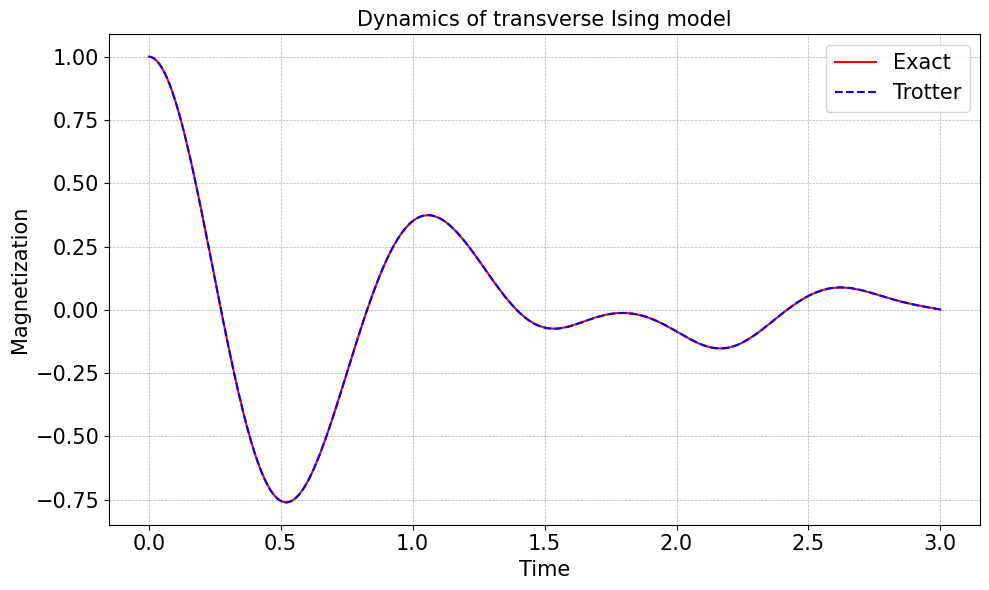

In [ ]:
 # パラメータ設定
n_qubits = 5
t = 3.0
M = 300
delta = t/M
h = 3.0

# 全スピンの磁化に対応する観測量を用意
magnetization_obs = Operator({pauli_label(f"Z{i}"): 1/n_qubits for i in range(n_qubits)})

def get_exact_time_evolution_circuit() -> QuantumCircuit:
    """時間ステップ delta の厳密な時間発展演算子を実装した量子回路を生成する
    """

    # ハミルトニアンの構築
    hamiltonian = Operator()
    for i in range(n_qubits):
        hamiltonian.add_term(pauli_label(f"Z{i} Z{(i+1)%n_qubits}"), 1)
        hamiltonian.add_term(pauli_label(f"X{i}"), h)
    hamiltonian_matrix = get_sparse_matrix(hamiltonian).toarray()

    # 厳密な時間発展回路
    exp_h = expm(-1j * hamiltonian_matrix * delta)
    circuit_exact_Ising = QuantumCircuit(n_qubits)
    circuit_exact_Ising.add_UnitaryMatrix_gate(range(n_qubits), exp_h)

    return circuit_exact_Ising

def get_trotter_time_evolution_circuit() -> QuantumCircuit:
    """時間ステップ delta の時間発展演算子をトロッター分解を用いて実装した量子回路を生成する
    """
    circuit_trotter_Ising = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        circuit_trotter_Ising.add_RX_gate(i, 2*delta*h)
        circuit_trotter_Ising.add_CNOT_gate(i, (i+1)%n_qubits)
        circuit_trotter_Ising.add_RZ_gate((i+1)%n_qubits, 2*delta)
        circuit_trotter_Ising.add_CNOT_gate(i, (i+1)%n_qubits)
    return circuit_trotter_Ising

# 期待値推定器の準備
estimator = create_qulacs_vector_estimator()

def run_time_evolution(
    initial_state: CircuitQuantumState,
    trotter_time_evo_circuit: QuantumCircuit,
    exact_time_evo_circuit: QuantumCircuit,
) -> tuple[list[float], list[float]]:
    """トロッター分解と厳密解の両方で時間発展を実行する
    """

    # 時間と平均磁化を記録するリスト
    y_trotter = []
    y_exact = []

    # t=0 における平均磁化を計算
    y_trotter.append(estimator(magnetization_obs, initial_state).value.real)
    y_exact.append(estimator(magnetization_obs, initial_state).value.real)

    # t>0 における平均磁化を計算
    n_qubits = initial_state.qubit_count
    for i in range(M):
        # 時間発展(delta = t/M)
        exact_circuit_i = QuantumCircuit(n_qubits, exact_time_evo_circuit.gates * (i+1))
        exact_state_i = apply_circuit(exact_circuit_i, initial_state)

        trotter_circuit_i = QuantumCircuit(n_qubits, trotter_time_evo_circuit.gates * (i+1))
        trotter_state_i = apply_circuit(trotter_circuit_i, initial_state)

        # 平均磁化を計算して記録
        y_exact.append(estimator(magnetization_obs, exact_state_i).value.real)
        y_trotter.append(estimator(magnetization_obs, trotter_state_i).value.real)

    return y_trotter, y_exact

# 初期状態を|00000>に設定
init_state = quantum_state(n_qubits)
circuit_exact_Ising = get_exact_time_evolution_circuit()
circuit_trotter_Ising = get_trotter_time_evolution_circuit()

y_trotter, y_exact = run_time_evolution(
    init_state, circuit_trotter_Ising, circuit_exact_Ising)
x = [i*delta for i in range(M+1)]

# グラフを描画
plt.figure(figsize=(10, 6))
plt.xlabel("Time", fontsize=15)
plt.ylabel("Magnetization", fontsize=15)
plt.title("Dynamics of transverse Ising model", fontsize=15)
plt.plot(x, y_exact, "-", label="Exact", color="red")
plt.plot(x, y_trotter, "--", label="Trotter", color="blue")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

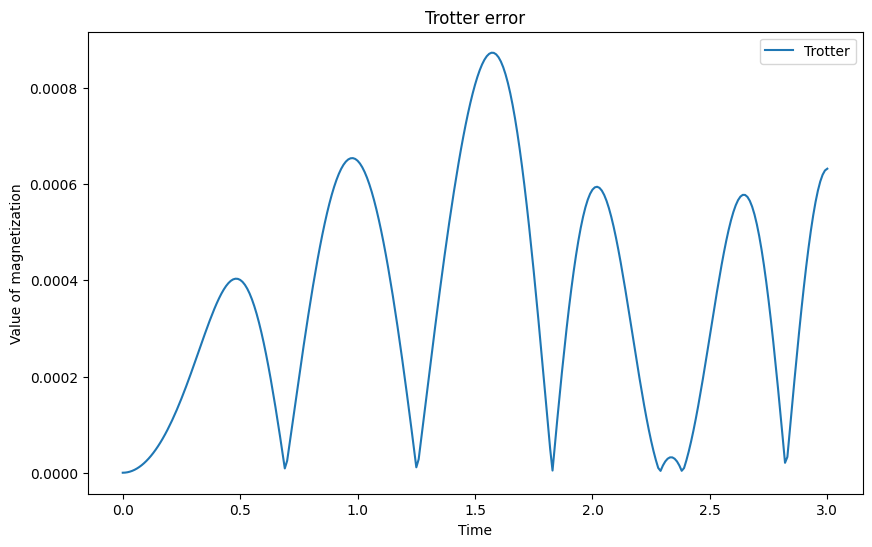

In [10]:
plt.figure(figsize=(10, 6))
plt.xlabel("Time")
plt.ylabel("Value of magnetization")
plt.title("Trotter error")
plt.plot(x, np.abs(np.array(y_trotter) - np.array(y_exact)), "-", label="Trotter")
plt.legend()
plt.show()